In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from boruta import BorutaPy

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from tqdm.notebook import tqdm
from sklearn.model_selection import GroupKFold

import warnings
warnings.filterwarnings("ignore")

In [6]:
Xdf = pd.read_csv('sway_features.csv')
Xdf['subj_id'] = Xdf.index
Xdf

,cohort,subj_id,year_x,sixmwd,fs,cadence_hz,step_time_cv_pct,acf_step_regularity,hr_ap,hr_vt,ml_rms_g,ml_spectral_entropy,jerk_mean_abs_gps,enmo_mean_g,cadence_slope_per_min,year_y,vt_rms_g,ml_over_enmo,ml_over_vt
0,C,0,2016,2147,30.0,1.757812,57.062069,0.837403,0.013381,0.006770,0.233140,0.717983,7.919919,0.245034,2.343750e-02,2016,0.548503,0.951458,0.425047
1,C,1,2016,2216,30.0,2.460938,8.467509,0.881826,0.007752,0.006578,0.263745,0.807063,9.211599,0.284253,-1.621585e-16,2016,0.491903,0.927855,0.536173
2,C,2,2016,2009,30.0,2.109375,9.497497,0.928834,0.004640,0.003535,0.187935,0.675369,5.864571,0.206654,-1.171875e-02,2016,0.420446,0.909420,0.446989
3,C,3,2016,1816,30.0,2.109375,6.942614,0.907162,0.071945,0.003958,0.164526,0.476990,4.851284,0.159849,0.000000e+00,2016,0.373603,1.029258,0.440376
4,C,4,2016,2323,30.0,2.109375,5.839634,0.937664,0.003039,0.000586,0.273992,0.769149,8.632483,0.319720,-3.515625e-02,2016,0.624647,0.856974,0.438635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,M,117,2024,1520,30.0,1.992188,76.236092,0.927048,0.053684,0.032141,0.257774,0.633545,5.553625,0.165208,-2.343750e-02,2024,0.341143,1.560299,0.755619
118,M,118,2024,1846,30.0,1.875000,94.953725,0.814743,0.048107,0.008925,0.235052,0.679036,4.741002,0.191791,-3.515625e-02,2024,0.327436,1.225565,0.717856
119,M,119,2024,1458,30.0,1.992188,6.413943,0.919438,0.015654,0.014846,0.188883,0.593221,6.113985,0.160987,-3.515625e-02,2024,0.295828,1.173278,0.638489
120,M,120,2025,1789,30.0,1.992188,89.402089,0.952011,0.013292,0.004478,0.234932,0.638054,4.431375,0.161792,8.107923e-17,2025,0.314925,1.452065,0.745995


In [20]:
Xdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cohort                 122 non-null    object 
 1   subj_id                122 non-null    int64  
 2   year_x                 122 non-null    int64  
 3   sixmwd                 122 non-null    int64  
 4   fs                     122 non-null    float64
 5   cadence_hz             122 non-null    float64
 6   step_time_cv_pct       122 non-null    float64
 7   acf_step_regularity    122 non-null    float64
 8   hr_ap                  122 non-null    float64
 9   hr_vt                  122 non-null    float64
 10  ml_rms_g               122 non-null    float64
 11  ml_spectral_entropy    122 non-null    float64
 12  jerk_mean_abs_gps      122 non-null    float64
 13  enmo_mean_g            122 non-null    float64
 14  cadence_slope_per_min  122 non-null    float64
 15  year_y

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

def plot_feature_relationship(df, feature_name, label_name='sixmwd'):
    """
    Plots scatter plot of feature vs label with best-fit regression line and Pearson correlation.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the feature and label columns.
    feature_name : str
        Name of the feature column to plot on the x-axis.
    label_name : str, default='label'
        Name of the target (label) column to plot on the y-axis.
    """
    if feature_name not in df.columns or label_name not in df.columns:
        raise ValueError(f"Both '{feature_name}' and '{label_name}' must exist in the dataframe.")

    # Drop NaN pairs
    data = df[[feature_name, label_name]].dropna()
    x = data[feature_name].values
    y = data[label_name].values

    # Compute linear best-fit line
    coeffs = np.polyfit(x, y, 1)
    line = np.poly1d(coeffs)

    # Compute Pearson correlation
    r, p = pearsonr(x, y)

    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.6, s=25, label='Data points')
    plt.plot(np.sort(x), line(np.sort(x)), color='red', linewidth=2,
             label=f'Pearson r={r:.3f}')
    plt.xlabel(feature_name)
    plt.ylabel(label_name)
    plt.title(f'Relationship between {feature_name} and {label_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

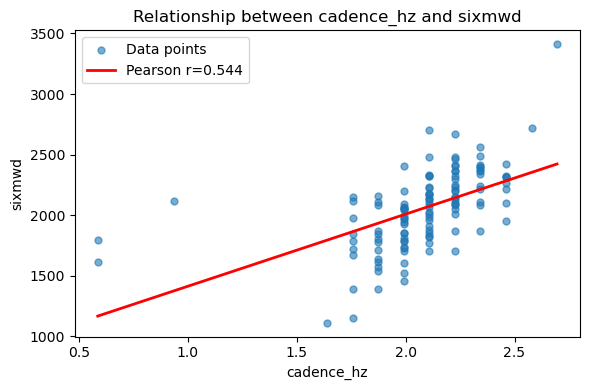

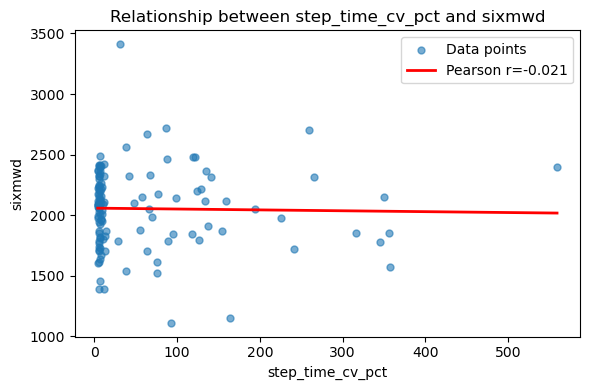

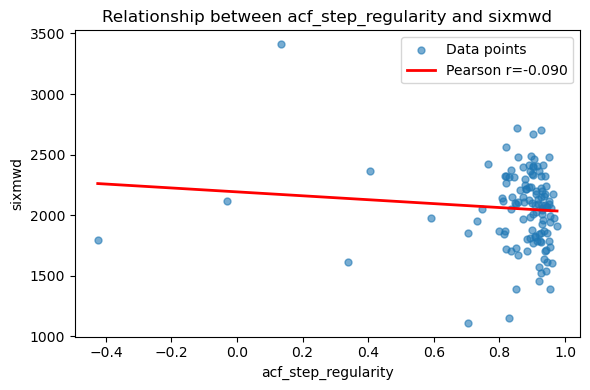

In [8]:
plot_feature_relationship(Xdf, 'cadence_hz')
plot_feature_relationship(Xdf, 'step_time_cv_pct')
plot_feature_relationship(Xdf, 'acf_step_regularity')

In [9]:
len(Xdf['subj_id'].unique())

122

In [30]:
# -------- Helper: correlation-based feature elimination --------
def correlation_filter(X, threshold=0.9):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return X.drop(columns=to_drop), to_drop


# -------- Main pipeline --------
def run_pipeline(Xdf):
    X = Xdf.drop(columns=['subj_id', 'year_x','sixmwd','fs','year_y','cohort'])
    y = Xdf['sixmwd'].values
    groups = Xdf['subj_id'].values
    
    models = {
        'KNN': KNeighborsRegressor(),
        'SVM': SVR(),
        'RandomForest': RandomForestRegressor(n_jobs=-1, random_state=42),
        'XGBoost': XGBRegressor(verbosity=0, n_jobs=-1),
        'Ridge': Ridge(),
        'Lasso': Lasso()
    }
    
    n_splits = 5
    gkf = GroupKFold(n_splits=n_splits)
    
    results = []
    
    for name, model in models.items():
        print(name)
        all_y_true, all_y_pred = [], []

        for train_idx, test_idx in gkf.split(X, y, groups=groups):
            X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
            y_train, y_test = y[train_idx], y[test_idx]
            
            # Step 1: correlation filter
            X_train_corr, dropped = correlation_filter(X_train, threshold=0.9)
            X_test_corr = X_test.drop(columns=dropped, errors='ignore')
            
            # Step 2: Boruta
            rf = RandomForestRegressor(n_jobs=-1, random_state=42)
            boruta = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42)
            boruta.fit(X_train_corr.values, y_train)
            selected = X_train_corr.columns[boruta.support_].tolist()
            
            X_train_sel = X_train_corr[selected]
            X_test_sel = X_test_corr[selected]
            
            # Step 3: Standardization
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_sel)
            X_test_scaled = scaler.transform(X_test_sel)
            
            # Step 4: Train and predict
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            
            all_y_true.extend(y_test)
            all_y_pred.extend(y_pred)
            
        
        # Compute metrics on pooled predictions
        all_y_true = np.array(all_y_true)
        all_y_pred = np.array(all_y_pred)
        
        mae = mean_absolute_error(all_y_true, all_y_pred)
        rmse = np.sqrt(mean_squared_error(all_y_true, all_y_pred))
        r2 = r2_score(all_y_true, all_y_pred)
        try:
            pearson, pp = pearsonr(all_y_true, all_y_pred)
            spearman, sp = spearmanr(all_y_true, all_y_pred)
        except:
            pearson = np.nan
        
        results.append({
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Pearson': pearson,
            'p_value': pp,
            'spearman':spearman,
            'sp_value': sp
        })
    
    return pd.DataFrame(results)

# Run pipeline
results_df = run_pipeline(Xdf)
print(results_df)

KNN
SVM
RandomForest
XGBoost
Ridge
Lasso
          Model         MAE        RMSE        R2   Pearson       p_value  \
0           KNN  193.560656  246.593868  0.428571  0.659397  1.478051e-16   
1           SVM  241.737797  320.631367  0.033928  0.503239  3.469437e-09   
2  RandomForest  199.611557  250.010227  0.412628  0.655395  2.592502e-16   
3       XGBoost  229.046621  292.444524  0.196318  0.537124  1.792322e-10   
4         Ridge  182.605175  240.370689  0.457049  0.676926  1.137013e-17   
5         Lasso  182.697508  240.600098  0.456012  0.676308  1.248367e-17   

   spearman      sp_value  
0  0.689741  1.554464e-18  
1  0.536962  1.819333e-10  
2  0.665312  6.341639e-17  
3  0.576746  3.592137e-12  
4  0.705514  1.160340e-19  
5  0.703915  1.521355e-19  


In [31]:
results_df

,Model,MAE,RMSE,R2,Pearson,p_value,spearman,sp_value
0,KNN,193.560656,246.593868,0.428571,0.659397,1.478051e-16,0.689741,1.554464e-18
1,SVM,241.737797,320.631367,0.033928,0.503239,3.469437e-09,0.536962,1.819333e-10
2,RandomForest,199.611557,250.010227,0.412628,0.655395,2.592502e-16,0.665312,6.341639e-17
3,XGBoost,229.046621,292.444524,0.196318,0.537124,1.792322e-10,0.576746,3.592137e-12
4,Ridge,182.605175,240.370689,0.457049,0.676926,1.137013e-17,0.705514,1.160340e-19
5,Lasso,182.697508,240.600098,0.456012,0.676308,1.248367e-17,0.703915,1.521355e-19


In [35]:
0.53**2

0.28090000000000004

  0%|          | 0/122 [00:00<?, ?it/s]

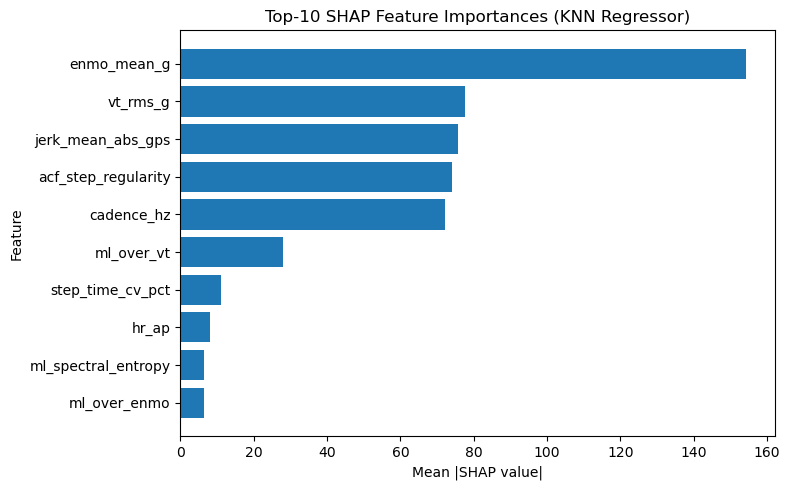

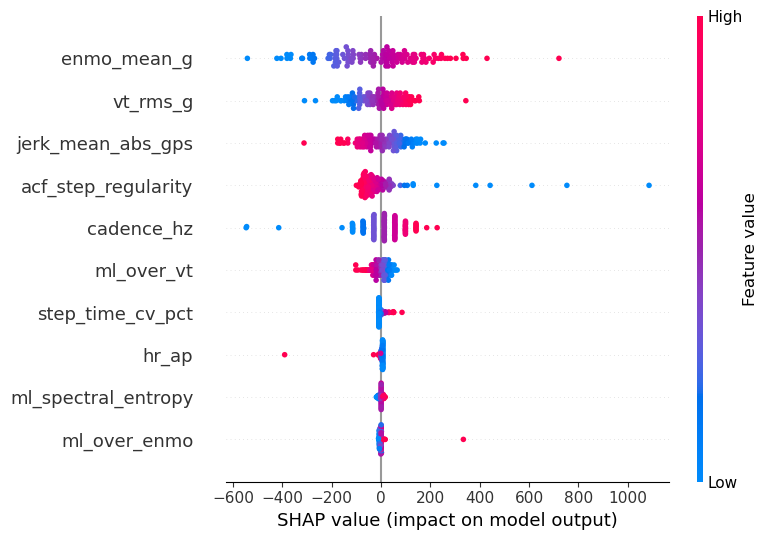

In [34]:
# SHAP feature importance for KNN Regressor (top-10 features, simplified — no imputation, no NaNs)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import shap
import os

df = Xdf  # your dataframe

# -------- 1) Prepare data --------
cols_to_drop = [c for c in ['subj_id', 'year_x','sixmwd','fs','year_y','cohort'] if c in df.columns]
X = df.drop(columns=cols_to_drop, errors='ignore').select_dtypes(include=[np.number]).copy()
y = df['sixmwd'].astype(float)

# Drop rows where either X or y has NaN
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].values

feature_names = np.array(X.columns)

# -------- 2) Simple pipeline: scale → KNN --------
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('Ridge', Ridge())
])
pipe.fit(X, y)


# -------- 3) SHAP setup (lightweight) --------
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

rng = np.random.RandomState(42)
bg_size = min(100, X.shape[0])
eval_size = min(300, X.shape[0])

X_bg = X.sample(bg_size, random_state=rng)
X_eval = X.sample(eval_size, random_state=rng)

# Plain callable for SHAP
def f_predict(x):
    return pipe.predict(pd.DataFrame(x, columns=X.columns))

explainer = shap.KernelExplainer(f_predict, X_bg)
shap_values = explainer.shap_values(X_eval, nsamples=100)  # reduce nsamples for faster compute

# -------- 4) Aggregate mean |SHAP| and plot top 10 --------
importance = np.abs(shap_values).mean(axis=0)
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance}).sort_values('importance', ascending=False)
top10 = imp_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10['feature'][::-1], top10['importance'][::-1])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top-10 SHAP Feature Importances (KNN Regressor)")
plt.tight_layout()
plt.show()

# Optional detailed summary:
shap.summary_plot(shap_values, X_eval, feature_names=feature_names, max_display=10)

In [15]:
Xdf = pd.read_csv('msfeature_table.csv')
Xdf

,pid,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,...,cf_75th,cf_95th,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label
0,C08,2016,51.023897,410.088694,423.181239,438.236986,462.633423,107.430062,0.059454,0.189782,...,4.388629,4.451012,0.465304,0.572599,0.584572,0.595714,0.607980,0.834633,0.068867,1786
1,M49,2022,4.978662,412.184952,440.429408,876.289591,1042.711814,317.171148,0.040618,0.191298,...,4.315504,4.424567,1.229656,0.534656,0.573749,0.591589,0.611791,0.933616,0.127287,1801
2,C23,2016,25.490999,425.043488,876.291870,5123.751941,5531.101925,2308.559364,0.060204,0.194204,...,5.707248,5.918230,1.638096,0.325080,0.345640,0.573735,0.601891,0.840418,0.172294,1947
3,C51,2017,77.773096,438.996211,1057.155411,2568.915499,5432.285745,2034.240886,0.105769,0.196857,...,4.779134,5.909338,1.423913,0.326343,0.452738,0.547686,0.593527,0.771453,0.150186,2079
4,M26,2025,178.414137,491.235100,1160.203172,1537.833523,5402.582175,1845.315986,0.141290,0.284822,...,4.406635,5.895116,1.276828,0.327901,0.514128,0.563343,0.592749,0.731599,0.136139,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,M50,2023,12.101514,621.402503,1244.290450,2021.393222,3666.854735,1270.304585,0.076169,0.283417,...,4.594819,5.452692,1.317926,0.414172,0.492861,0.539505,0.617199,1.339892,0.329485,2012
160,M07,2016,12.109741,626.087405,1250.855374,2019.731724,3660.128108,1267.067148,0.076373,0.283810,...,4.604658,5.451088,1.316701,0.411879,0.491615,0.538943,0.616322,1.337617,0.329115,2084
161,M02,2022,12.345716,627.025590,1243.168016,2014.583289,3651.245707,1264.597419,0.076897,0.284333,...,4.601345,5.449242,1.318900,0.412055,0.492039,0.539543,0.618874,1.333975,0.328122,2269
162,C09,2016,12.573334,631.214647,1234.697429,2009.857957,3642.909483,1261.200199,0.077343,0.284742,...,4.597777,5.447904,1.315043,0.412244,0.492489,0.540070,0.619492,1.330550,0.327162,2207


In [17]:
df_M = Xdf[Xdf['pid'].str.startswith('M')].reset_index(drop=True)
df_M

,pid,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,...,cf_75th,cf_95th,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label
0,M49,2022,4.978662,412.184952,440.429408,876.289591,1042.711814,317.171148,0.040618,0.191298,...,4.315504,4.424567,1.229656,0.534656,0.573749,0.591589,0.611791,0.933616,0.127287,1801
1,M26,2025,178.414137,491.235100,1160.203172,1537.833523,5402.582175,1845.315986,0.141290,0.284822,...,4.406635,5.895116,1.276828,0.327901,0.514128,0.563343,0.592749,0.731599,0.136139,2022
2,M29,2024,273.562406,843.034988,1040.750081,1427.852567,5377.165331,1717.640563,0.180411,0.275250,...,4.416113,5.870364,1.172690,0.329452,0.506549,0.543756,0.587239,0.645644,0.124851,1611
3,M57,2024,308.167590,864.300332,1142.237837,1508.616027,5348.749798,1598.099386,0.186911,0.278571,...,4.455846,5.853900,1.124044,0.331014,0.503502,0.533300,0.584394,0.668517,0.159413,1520
4,M36,2022,155.055752,434.843580,1016.014448,1462.086619,5322.878766,1571.391452,0.185468,0.281141,...,4.427051,5.846432,1.400382,0.332408,0.507413,0.547167,0.601030,0.779172,0.182950,1761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,M23,2023,11.939069,596.478367,1223.132468,1974.830804,3715.871700,1279.404278,0.075957,0.280475,...,4.584660,5.458731,1.324234,0.414547,0.493316,0.538687,0.621715,1.356424,0.330691,1546
92,M37,2025,12.090564,600.590694,1231.972107,1979.896544,3704.064861,1275.982635,0.076469,0.281201,...,4.582156,5.456807,1.320553,0.414776,0.493780,0.539140,0.620713,1.352397,0.329673,2057
93,M50,2023,12.101514,621.402503,1244.290450,2021.393222,3666.854735,1270.304585,0.076169,0.283417,...,4.594819,5.452692,1.317926,0.414172,0.492861,0.539505,0.617199,1.339892,0.329485,2012
94,M07,2016,12.109741,626.087405,1250.855374,2019.731724,3660.128108,1267.067148,0.076373,0.283810,...,4.604658,5.451088,1.316701,0.411879,0.491615,0.538943,0.616322,1.337617,0.329115,2084


In [19]:
# Step 1: Sort visits chronologically within each subject
df_M_sorted = df_M.sort_values(['pid', 'year'])

# Step 2: Compute successive differences for all numeric columns per subject
df_diff = df_M_sorted.groupby('pid').diff()

# Step 3: Bring back identifying columns
df_diff['pid'] = df_M_sorted['pid']
df_diff['year'] = df_M_sorted['year']

# Step 4: (Optional) drop rows with all-NaN diffs (i.e. each subject's first visit)
df_diff = df_diff.dropna(subset=df_M.columns.difference(['pid', 'year']), how='all').reset_index(drop=True)
df_diff

,year,jerk_5th,jerk_25th,jerk_median,jerk_75th,jerk_95th,jerk_std,dist_5th,dist_25th,dist_median,...,cf_95th,cf_std,fd_5th,fd_25th,fd_median,fd_75th,fd_95th,fd_std,label,pid
0,2022,-16.994888,198.987221,338.338528,772.835624,-290.538952,92.848365,-0.035069,0.010447,0.037171,...,-0.293396,-0.118018,0.028573,-0.027186,-0.042053,-0.075653,0.145570,0.036160,328.0,M02
1,2025,-3.970723,-21.176463,-0.745949,83.118593,471.134611,17.927430,-0.009458,0.006622,0.004071,...,0.080446,0.104015,-0.013732,-0.004031,-0.003493,0.003894,0.063907,0.013156,240.0,M02
2,2025,-6.243818,-63.003254,53.831555,205.363932,-36.369802,30.251719,-0.021699,-0.000134,0.003398,...,0.014625,-0.000677,-0.019393,-0.012931,-0.010989,-0.004684,0.068246,0.012910,311.0,M04
3,2019,1.940695,-41.444260,-68.538605,-130.369463,-341.590002,19.637464,0.005644,-0.014317,-0.010374,...,-0.057565,-0.078690,0.015394,0.007926,0.004064,0.006324,-0.021688,-0.004937,-583.0,M06
4,2022,0.656460,2.384863,-31.461656,-60.598742,416.604299,-31.152661,0.001494,0.012497,0.001533,...,0.106689,0.122170,-0.008970,-0.002220,0.005858,0.007632,-0.024761,-0.011776,289.0,M06
5,2025,19.792349,-146.049894,-231.387337,-685.097397,-666.449470,-117.215341,0.033587,-0.015483,-0.033921,...,0.155106,-0.048651,-0.011271,0.022705,0.032793,0.057558,-0.110800,-0.031023,38.0,M06
6,2019,21.543558,120.319217,33.097389,-56.761559,50.981382,12.181546,0.042939,0.002530,0.003580,...,0.042421,-0.104129,0.009709,0.013951,0.003336,-0.008233,-0.089907,-0.011331,-35.0,M10
7,2024,-21.193128,-93.920945,-23.830741,106.248338,158.284882,26.582128,-0.042754,-0.001391,-0.002850,...,0.031394,0.104203,-0.017046,-0.016055,-0.006221,0.002273,0.072187,0.014074,-152.0,M10
8,2019,-2.597260,38.856153,11.745519,74.089646,258.772285,-38.702996,-0.006622,0.009990,0.003312,...,0.042218,0.064074,-0.013165,-0.005122,-0.003129,-0.007684,0.041934,0.003205,-265.0,M12
9,2025,14.994623,-319.780008,-226.483642,-663.696752,1233.535186,213.809756,0.008810,-0.036955,-0.031673,...,0.306501,0.115236,-0.064246,0.022464,0.018020,0.030397,-0.424845,-0.045757,209.0,M12


In [22]:
len(df_diff['pid'].unique())

27

In [26]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from boruta import BorutaPy
from scipy.stats import pearsonr
from tqdm import tqdm

def correlation_filter(X: pd.DataFrame, threshold: float = 0.9):
    Xn = X.select_dtypes(include=[np.number]).copy()
    if Xn.shape[1] <= 1:
        return Xn, []
    corr = Xn.corr().abs().fillna(0.0)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if (upper[c] > threshold).any()]
    return Xn.drop(columns=to_drop, errors='ignore'), to_drop

def run_pipeline(
    Xdf: pd.DataFrame,
    n_splits: int = 9,
    corr_threshold: float = 0.9,
    rf_top_k: int = 10,
    max_nan_frac: float = 0.30
):
    # keep only numeric features (pid, label preserved separately)
    base_X = Xdf.drop(columns=['pid', 'label']).select_dtypes(include=[np.number]).copy()
    Xdf_clean = pd.concat([Xdf[['pid', 'label']].reset_index(drop=True),
                           base_X.reset_index(drop=True)], axis=1)

    X = Xdf_clean.drop(columns=['pid', 'label'])
    y = Xdf_clean['label'].values
    groups = Xdf_clean['pid'].values

    models = {
        'KNN': KNeighborsRegressor(),
        'SVM': SVR(),
        'RandomForest': RandomForestRegressor(n_jobs=-1, random_state=42),
        'XGBoost': XGBRegressor(verbosity=0, n_jobs=-1, random_state=42),
        'Ridge': Ridge(),
        'Lasso': Lasso(),
        'MLP': MLPRegressor(max_iter=500, random_state=42)
    }

    gkf = GroupKFold(n_splits=n_splits)
    results = []

    for name, model in tqdm(models.items()):
        all_y_true, all_y_pred = [], []

        for train_idx, test_idx in gkf.split(X, y, groups=groups):
            X_train_raw, X_test_raw = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
            y_train, y_test = y[train_idx], y[test_idx]

            # 0) drop columns with excessive missingness (based on TRAIN only)
            nan_frac = X_train_raw.isna().mean()
            cols_keep = nan_frac[nan_frac <= max_nan_frac].index.tolist()
            if len(cols_keep) == 0:
                # if everything exceeds threshold, keep all and let imputer handle it
                cols_keep = X_train_raw.columns.tolist()
            X_train_raw = X_train_raw[cols_keep]
            X_test_raw = X_test_raw[cols_keep]

            # 1) impute NaNs (median) to satisfy Boruta/scikit-learn
            imputer = SimpleImputer(strategy='median')
            X_train_imp = imputer.fit_transform(X_train_raw)
            X_test_imp = imputer.transform(X_test_raw)
            X_train_imp = pd.DataFrame(X_train_imp, columns=cols_keep, index=X_train_raw.index)
            X_test_imp  = pd.DataFrame(X_test_imp,  columns=cols_keep, index=X_test_raw.index)

            # 2) remove zero-variance features (post-impute)
            vt = VarianceThreshold(threshold=0.0)
            X_train_vt = vt.fit_transform(X_train_imp)
            kept_vt_cols = [c for c, m in zip(cols_keep, vt.get_support()) if m]
            if len(kept_vt_cols) == 0:
                # fallback: keep all post-impute columns
                X_train_vt = X_train_imp.values
                kept_vt_cols = cols_keep
            X_test_vt = vt.transform(X_test_imp) if hasattr(vt, "get_support") else X_test_imp.values
            X_train_vt = pd.DataFrame(X_train_vt, columns=kept_vt_cols, index=X_train_imp.index)
            X_test_vt  = pd.DataFrame(X_test_vt,  columns=kept_vt_cols, index=X_test_imp.index)

            # 3) correlation filter (NaN-free now)
            X_train_corr, dropped = correlation_filter(X_train_vt, threshold=corr_threshold)
            if X_train_corr.shape[1] == 0:
                X_train_corr = X_train_vt.copy()
                dropped = []
            X_test_corr = X_test_vt.drop(columns=dropped, errors='ignore')
            X_test_corr = X_test_corr[X_train_corr.columns]  # align

            # 4) Boruta with fallbacks
            rf = RandomForestRegressor(n_jobs=-1, random_state=42)
            boruta = BorutaPy(estimator=rf, n_estimators='auto', verbose=0, random_state=42)
            boruta.fit(X_train_corr.values, y_train)

            mask = boruta.support_ | getattr(boruta, 'support_weak_', np.zeros_like(boruta.support_, dtype=bool))
            selected_cols = X_train_corr.columns[mask].tolist()

            if len(selected_cols) == 0:
                rf.fit(X_train_corr, y_train)
                importances = rf.feature_importances_
                order = np.argsort(importances)[::-1]
                k = min(rf_top_k, X_train_corr.shape[1])
                selected_cols = X_train_corr.columns[order[:k]].tolist()

            if len(selected_cols) == 0:
                selected_cols = X_train_corr.columns.tolist()

            X_train_sel = X_train_corr[selected_cols]
            X_test_sel = X_test_corr[selected_cols]

            # 5) scale
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_sel)
            X_test_scaled = scaler.transform(X_test_sel)

            # 6) fit and predict
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)

            all_y_true.extend(y_test)
            all_y_pred.extend(y_pred)

        all_y_true = np.array(all_y_true)
        all_y_pred = np.array(all_y_pred)

        mae = mean_absolute_error(all_y_true, all_y_pred)
        rmse = np.sqrt(mean_squared_error(all_y_true, all_y_pred))
        r2 = r2_score(all_y_true, all_y_pred)
        pearson = np.nan
        if np.unique(all_y_pred).size > 1:
            try:
                pearson = pearsonr(all_y_true, all_y_pred)[0]
            except Exception:
                pass

        results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Pearson': pearson})

    return pd.DataFrame(results)

def build_delta_frame(df_M: pd.DataFrame) -> pd.DataFrame:
    df_sorted = df_M.sort_values(['pid', 'year']).reset_index(drop=True)
    diffs = df_sorted.groupby('pid').diff()
    diffs['pid'] = df_sorted['pid']
    diffs['year'] = df_sorted['year']
    diffs = diffs.dropna(subset=['label']).reset_index(drop=True)
    # ensure only numeric features + pid + label
    numeric = diffs.select_dtypes(include=[np.number]).copy()
    numeric['pid'] = diffs['pid']
    numeric = numeric.rename(columns={'label': 'label'})
    return numeric

# Example:
Xdf_diff = build_delta_frame(df_M)
results_df_diff = run_pipeline(Xdf_diff, n_splits=9, corr_threshold=0.9, rf_top_k=10, max_nan_frac=0.30)
print(results_df_diff)

 86%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                         | 6/7 [03:46<00:37, 37.68s/it]/mnt/sdb/arafat/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/sdb/arafat/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/sdb/arafat/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/sdb/arafat/anaconda3/lib/python3.12/site-packages/sk

          Model         MAE        RMSE        R2   Pearson
0           KNN  188.845455  227.919798 -0.156869  0.072838
1           SVM  179.850488  217.365104 -0.052203 -0.259972
2  RandomForest  193.700682  236.215986 -0.242620 -0.068850
3       XGBoost  205.862078  248.147324 -0.371321  0.060667
4         Ridge  180.280442  211.976466 -0.000680  0.257401
5         Lasso  178.664826  211.526634  0.003563  0.269107
6           MLP  174.755514  208.008831  0.036430  0.210616


In [27]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from boruta import BorutaPy
from tqdm import tqdm

# ---------- MDC from ICC ----------
def compute_mdc_from_icc(df_all: pd.DataFrame, label_col: str = 'label', icc: float = 0.95) -> float:
    """
    SEM = sigma_m * sqrt(1 - ICC)
    MDC(95%) = 1.96 * SEM * sqrt(2)
    Here sigma_m is the sample SD of the label scores across observations.
    """
    sigma_m = np.nanstd(df_all[label_col].values, ddof=1)
    sem = sigma_m * np.sqrt(1.0 - icc)
    mdc = 1.96 * sem * np.sqrt(2.0)
    return float(mdc)

# ---------- Δ-frame (visit-to-visit differences) ----------
def build_delta_frame(df_M: pd.DataFrame) -> pd.DataFrame:
    # sort and difference numeric columns per subject
    df_sorted = df_M.sort_values(['pid', 'year']).reset_index(drop=True)
    diffs = df_sorted.groupby('pid').diff()
    # reattach identifiers
    diffs['pid']  = df_sorted['pid']
    diffs['year'] = df_sorted['year']
    # keep rows where Δlabel is defined
    diffs = diffs.dropna(subset=['label']).reset_index(drop=True)
    return diffs  # 'label' column is already Δlabel here

# ---------- Correlation filter (NaN-safe upstream via imputation) ----------
def correlation_filter(X: pd.DataFrame, threshold: float = 0.9):
    Xn = X.select_dtypes(include=[np.number]).copy()
    if Xn.shape[1] <= 1:
        return Xn, []
    corr = Xn.corr().abs().fillna(0.0)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if (upper[c] > threshold).any()]
    return Xn.drop(columns=to_drop, errors='ignore'), to_drop

# ---------- Group-aware classification pipeline ----------
def run_pipeline_classification(
    Xdf: pd.DataFrame,
    n_splits: int = 9,
    corr_threshold: float = 0.9,
    rf_top_k: int = 10,
    max_nan_frac: float = 0.30
):
    # keep only numeric features (pid, label preserved separately)
    base_X = Xdf.drop(columns=['pid', 'label']).select_dtypes(include=[np.number]).copy()
    Xdf_clean = pd.concat([Xdf[['pid', 'label']].reset_index(drop=True),
                           base_X.reset_index(drop=True)], axis=1)

    X = Xdf_clean.drop(columns=['pid', 'label'])
    y = Xdf_clean['label'].values.astype(int)
    groups = Xdf_clean['pid'].values

    models = {
        'KNN': KNeighborsClassifier(),
        'SVM': SVC(probability=True, random_state=42),
        'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced'),
        'XGBoost': XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss'),
        'LogReg': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
        'MLP': MLPClassifier(max_iter=500, random_state=42)
    }

    gkf = GroupKFold(n_splits=n_splits)
    rows = []

    for name, model in tqdm(models.items()):
        y_true_all, y_pred_all, y_prob_all = [], [], []

        for tr, te in gkf.split(X, y, groups=groups):
            Xtr_raw, Xte_raw = X.iloc[tr].copy(), X.iloc[te].copy()
            ytr, yte = y[tr], y[te]

            # 0) drop columns with excessive missingness (train-driven)
            nan_frac = Xtr_raw.isna().mean()
            cols_keep = nan_frac[nan_frac <= max_nan_frac].index.tolist()
            if len(cols_keep) == 0:
                cols_keep = Xtr_raw.columns.tolist()
            Xtr_raw = Xtr_raw[cols_keep]
            Xte_raw = Xte_raw[cols_keep]

            # 1) impute NaNs (median)
            imputer = SimpleImputer(strategy='median')
            Xtr_imp = pd.DataFrame(imputer.fit_transform(Xtr_raw), columns=cols_keep, index=Xtr_raw.index)
            Xte_imp = pd.DataFrame(imputer.transform(Xte_raw),     columns=cols_keep, index=Xte_raw.index)

            # 2) remove zero-variance features
            vt = VarianceThreshold(threshold=0.0)
            Xtr_vt = vt.fit_transform(Xtr_imp)
            kept_vt_cols = [c for c, m in zip(cols_keep, vt.get_support()) if m]
            if len(kept_vt_cols) == 0:
                Xtr_vt = Xtr_imp.values
                kept_vt_cols = cols_keep
            Xte_vt = vt.transform(Xte_imp) if hasattr(vt, "get_support") else Xte_imp.values
            Xtr_vt = pd.DataFrame(Xtr_vt, columns=kept_vt_cols, index=Xtr_imp.index)
            Xte_vt = pd.DataFrame(Xte_vt, columns=kept_vt_cols, index=Xte_imp.index)

            # 3) correlation filter
            Xtr_corr, dropped = correlation_filter(Xtr_vt, threshold=corr_threshold)
            if Xtr_corr.shape[1] == 0:
                Xtr_corr = Xtr_vt.copy(); dropped = []
            Xte_corr = Xte_vt.drop(columns=dropped, errors='ignore')
            Xte_corr = Xte_corr[Xtr_corr.columns]

            # 4) Boruta (classifier) with fallbacks
            rf_cls = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')
            boruta = BorutaPy(estimator=rf_cls, n_estimators='auto', verbose=0, random_state=42)
            boruta.fit(Xtr_corr.values, ytr)

            mask = boruta.support_ | getattr(boruta, 'support_weak_', np.zeros_like(boruta.support_, dtype=bool))
            selected_cols = Xtr_corr.columns[mask].tolist()

            if len(selected_cols) == 0:
                rf_cls.fit(Xtr_corr, ytr)
                imps = rf_cls.feature_importances_
                order = np.argsort(imps)[::-1]
                k = min(rf_top_k, Xtr_corr.shape[1])
                selected_cols = Xtr_corr.columns[order[:k]].tolist()

            if len(selected_cols) == 0:
                selected_cols = Xtr_corr.columns.tolist()

            Xtr_sel = Xtr_corr[selected_cols]
            Xte_sel = Xte_corr[selected_cols]

            # 5) scale
            scaler = StandardScaler()
            Xtr_scaled = scaler.fit_transform(Xtr_sel)
            Xte_scaled = scaler.transform(Xte_sel)

            # 6) fit & predict
            model.fit(Xtr_scaled, ytr)
            y_pred = model.predict(Xte_scaled)
            # probability or decision function for AUROC
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(Xte_scaled)[:, 1]
            elif hasattr(model, "decision_function"):
                # map decision scores to 0-1 via rank-based scaling if needed
                scores = model.decision_function(Xte_scaled)
                # robust min-max (avoid zero division)
                smin, smax = np.min(scores), np.max(scores)
                y_prob = (scores - smin) / (smax - smin + 1e-12)
            else:
                y_prob = np.full_like(y_pred, fill_value=np.nan, dtype=float)

            y_true_all.extend(yte.tolist())
            y_pred_all.extend(y_pred.tolist())
            y_prob_all.extend(y_prob.tolist())

        y_true_all = np.asarray(y_true_all)
        y_pred_all = np.asarray(y_pred_all)
        y_prob_all = np.asarray(y_prob_all)

        acc  = accuracy_score(y_true_all, y_pred_all)
        bacc = balanced_accuracy_score(y_true_all, y_pred_all)
        f1   = f1_score(y_true_all, y_pred_all, zero_division=0)
        try:
            auroc = roc_auc_score(y_true_all, y_prob_all)
        except Exception:
            auroc = np.nan

        rows.append({
            'Model': name,
            'Accuracy': acc,
            'BalancedAcc': bacc,
            'F1': f1,
            'AUROC': auroc
        })

    return pd.DataFrame(rows)

In [28]:
# 1) compute MDC from pooled label SD with ICC=0.95
mdc = compute_mdc_from_icc(df_M, label_col='label', icc=0.95)
print("MDC(95%):", mdc)

# 2) Δ-frame (Δfeatures and Δlabel)
df_delta = build_delta_frame(df_M)    # here df_delta['label'] is Δlabel

# 3) binarize: 1 if |Δlabel| >= MDC, else 0
y_binary = (df_delta['label'].abs() >= mdc).astype(int)

# 4) assemble classification frame: keep pid + binary label + features
Xdf_bin = df_delta.copy()
Xdf_bin['label'] = y_binary  # overwrite Δlabel with binary target for the pipeline

# 5) run group-aware classification pipeline
results_cls = run_pipeline_classification(
    Xdf=Xdf_bin,
    n_splits=9,
    corr_threshold=0.9,
    rf_top_k=10,
    max_nan_frac=0.30
)
print(results_cls)

MDC(95%): 172.89295730666893


 83%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                             | 5/6 [05:59<01:11, 71.85s/it]/mnt/sdb/arafat/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/sdb/arafat/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/sdb/arafat/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/sdb/arafat/anaconda3/lib/python3.12/site-packages/sk

          Model  Accuracy  BalancedAcc        F1     AUROC
0           KNN  0.431818     0.429607  0.390244  0.400621
1           SVM  0.409091     0.405797  0.350000  0.273292
2  RandomForest  0.522727     0.524845  0.533333  0.460663
3       XGBoost  0.363636     0.364389  0.363636  0.408903
4        LogReg  0.522727     0.520704  0.487805  0.496894
5           MLP  0.454545     0.457557  0.478261  0.426501


In [31]:
Xdf_bin['label'].value_counts()

label
0    23
1    21
Name: count, dtype: int64